In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE_PATH = '/content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP'
APTOS_PATH = os.path.join(BASE_PATH, 'aptos2019_sorted')
MESSIDOR_PATH = os.path.join(BASE_PATH, 'messidor/messidor_organized')
KAGGLE_DR_PATH = os.path.join(BASE_PATH, 'kaggle_dr')
RESULTS_PATH = os.path.join(BASE_PATH, 'Transfer_learning_results')

os.makedirs(RESULTS_PATH, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.00005  # i lowered learning rate for better stability

print("EfficientNetB3 Transfer Learning - Setup Complete")
print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Maximum Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"\nResults Directory: {RESULTS_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EfficientNetB3 Transfer Learning - Setup Complete
Image Size: (224, 224)
Batch Size: 32
Maximum Epochs: 30
Learning Rate: 5e-05

Results Directory: /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/Transfer_learning_results


In [7]:
print("Building EfficientNetB3 Transfer Learning Model")

keras.backend.clear_session()

# Load pre-trained EfficientNetB3 base model
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3)
)

base_model.trainable = False

print(f"\nBase model loaded successfully")
print(f"Total base layers: {len(base_model.layers)}")
print(f"Pre-trained weights: Frozen")

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

# Calculate parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen_params = total_params - trainable_params

print(f"\nModel Architecture Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters: {frozen_params:,}")
print(f"  Percentage trainable: {(trainable_params/total_params)*100:.1f}%")

model.summary()

Building EfficientNetB3 Transfer Learning Model

Base model loaded successfully
Total base layers: 385
Pre-trained weights: Frozen

Model Architecture Summary:
  Total parameters: 11,177,264
  Trainable parameters: 393,729
  Frozen parameters: 10,783,535
  Percentage trainable: 3.5%


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,264 (42.64 MB)

 Trainable params: 393,729 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [8]:
print("Loading and Preparing Data")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("\nLoading training images...")
train_generator = train_datagen.flow_from_directory(
    APTOS_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

print("Loading validation images...")
val_generator = val_datagen.flow_from_directory(
    APTOS_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)
print(f"\nData Loading Complete")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Class mapping: {train_generator.class_indices}")

train_healthy = np.sum(train_generator.classes == 0)
train_unhealthy = np.sum(train_generator.classes == 1)

print(f"\nTraining Set Distribution:")
print(f"  Healthy: {train_healthy} ({train_healthy/train_generator.samples*100:.1f}%)")
print(f"  Unhealthy: {train_unhealthy} ({train_unhealthy/train_generator.samples*100:.1f}%)")

Loading and Preparing Data

Loading training images...
Found 1835 images belonging to 2 classes.
Loading validation images...
Found 458 images belonging to 2 classes.

Data Loading Complete
Training samples: 1835
Validation samples: 458
Class mapping: {'healthy': 0, 'unhealthy': 1}

Training Set Distribution:
  Healthy: 926 (50.5%)
  Unhealthy: 909 (49.5%)


In [9]:
print("Training EfficientNetB3 Model")

# Configures training callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(RESULTS_PATH, 'efficientnetb3_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Beginss training
start_time = datetime.now()
print(f"\nTraining started: {start_time.strftime('%H:%M:%S')}")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

end_time = datetime.now()
training_time = end_time - start_time

print("Training Completed")
print(f"Total training time: {training_time}")
print(f"Epochs completed: {len(history.history['loss'])}")

Training EfficientNetB3 Model

Training started: 19:49:54
Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5164 - auc: 0.5054 - loss: 0.7011 - precision: 0.5072 - recall: 0.4673
Epoch 1: val_accuracy improved from -inf to 0.50437, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/Transfer_learning_results/efficientnetb3_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 682s 11s/step - accuracy: 0.5163 - auc: 0.5056 - loss: 0.7011 - precision: 0.5073 - recall: 0.4681 - val_accuracy: 0.5044 - val_auc: 0.7074 - val_loss: 0.6979 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-05
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4860 - auc: 0.4935 - loss: 0.7057 - precision: 0.4895 - recall: 0.3925
Epoch 2: val_accuracy did not improve from 0.50437
58/58 ━━━━━━━━━━━━━━━━━━━━ 621s 11s/step - accuracy: 0.4862 - auc: 0.4935 - loss: 0.7056 - precision: 0.4895 - recall: 0.3932 - val_accuracy: 0.5044 - val_auc: 0.8108 - val_loss: 0.6901 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-05
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5024 - auc: 0.5032 - loss: 0.6999 - precision: 0.4944 - recall: 0.3877
Epoch 3: val_accuracy improved from 0.50437 to 0.72052, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/Transfer_learning_

58/58 ━━━━━━━━━━━━━━━━━━━━ 620s 11s/step - accuracy: 0.5024 - auc: 0.5032 - loss: 0.6998 - precision: 0.4945 - recall: 0.3888 - val_accuracy: 0.7205 - val_auc: 0.8144 - val_loss: 0.6894 - val_precision: 0.8235 - val_recall: 0.5551 - learning_rate: 5.0000e-05
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4663 - auc: 0.4772 - loss: 0.7001 - precision: 0.4695 - recall: 0.4323
Epoch 4: val_accuracy did not improve from 0.72052
58/58 ━━━━━━━━━━━━━━━━━━━━ 624s 11s/step - accuracy: 0.4667 - auc: 0.4777 - loss: 0.7001 - precision: 0.4698 - recall: 0.4327 - val_accuracy: 0.4956 - val_auc: 0.8116 - val_loss: 0.6913 - val_precision: 0.4956 - val_recall: 1.0000 - learning_rate: 5.0000e-05
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5312 - auc: 0.5356 - loss: 0.6918 - precision: 0.5265 - recall: 0.5226
Epoch 5: val_accuracy did not improve from 0.72052
58/58 ━━━━━━━━━━━━━━━━━━━━ 622s 11s/step - accuracy: 0.5311 - auc: 0.5353 - loss: 0.6919 - precision: 0.5264 - r

58/58 ━━━━━━━━━━━━━━━━━━━━ 624s 11s/step - accuracy: 0.5052 - auc: 0.5105 - loss: 0.6945 - precision: 0.4999 - recall: 0.4209 - val_accuracy: 0.7511 - val_auc: 0.8430 - val_loss: 0.6877 - val_precision: 0.7958 - val_recall: 0.6696 - learning_rate: 5.0000e-05
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5141 - auc: 0.5105 - loss: 0.6935 - precision: 0.4964 - recall: 0.2559
Epoch 12: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 12: val_accuracy did not improve from 0.75109
58/58 ━━━━━━━━━━━━━━━━━━━━ 625s 11s/step - accuracy: 0.5140 - auc: 0.5106 - loss: 0.6935 - precision: 0.4966 - recall: 0.2579 - val_accuracy: 0.4956 - val_auc: 0.8182 - val_loss: 0.6940 - val_precision: 0.4956 - val_recall: 1.0000 - learning_rate: 5.0000e-05
Epoch 13/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4708 - auc: 0.5031 - loss: 0.6982 - precision: 0.4707 - recall: 0.7326
Epoch 13: val_accuracy did not improve from 0.75109
58/58 ━━━━━━━━━━━━━━━━━━━━ 617

58/58 ━━━━━━━━━━━━━━━━━━━━ 630s 11s/step - accuracy: 0.5201 - auc: 0.5312 - loss: 0.6915 - precision: 0.5203 - recall: 0.5618 - val_accuracy: 0.7751 - val_auc: 0.8528 - val_loss: 0.6873 - val_precision: 0.6975 - val_recall: 0.9648 - learning_rate: 2.5000e-05
Epoch 16/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5202 - auc: 0.5187 - loss: 0.6925 - precision: 0.5274 - recall: 0.4660
Epoch 16: val_accuracy improved from 0.77511 to 0.78384, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/Transfer_learning_results/efficientnetb3_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 640s 11s/step - accuracy: 0.5205 - auc: 0.5191 - loss: 0.6925 - precision: 0.5276 - recall: 0.4657 - val_accuracy: 0.7838 - val_auc: 0.8343 - val_loss: 0.6871 - val_precision: 0.7857 - val_recall: 0.7753 - learning_rate: 2.5000e-05
Epoch 17/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5648 - auc: 0.5787 - loss: 0.6872 - precision: 0.5723 - recall: 0.4451
Epoch 17: val_accuracy did not improve from 0.78384
58/58 ━━━━━━━━━━━━━━━━━━━━ 693s 11s/step - accuracy: 0.5647 - auc: 0.5784 - loss: 0.6873 - precision: 0.5722 - recall: 0.4448 - val_accuracy: 0.7642 - val_auc: 0.8433 - val_loss: 0.6863 - val_precision: 0.7874 - val_recall: 0.7181 - learning_rate: 2.5000e-05
Epoch 18/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5327 - auc: 0.5436 - loss: 0.6900 - precision: 0.5211 - recall: 0.3433
Epoch 18: val_accuracy did not improve from 0.78384
58/58 ━━━━━━━━━━━━━━━━━━━━ 623s 11s/step - accuracy: 0.5325 - auc: 0.5433 - loss: 0.6901 - precision: 0.5210

58/58 ━━━━━━━━━━━━━━━━━━━━ 630s 11s/step - accuracy: 0.5540 - auc: 0.5725 - loss: 0.6881 - precision: 0.5690 - recall: 0.4566 - val_accuracy: 0.8057 - val_auc: 0.8441 - val_loss: 0.6850 - val_precision: 0.7695 - val_recall: 0.8678 - learning_rate: 2.5000e-05
Epoch 23/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5410 - auc: 0.5551 - loss: 0.6894 - precision: 0.5547 - recall: 0.3654
Epoch 23: val_accuracy did not improve from 0.80568
58/58 ━━━━━━━━━━━━━━━━━━━━ 627s 11s/step - accuracy: 0.5410 - auc: 0.5551 - loss: 0.6894 - precision: 0.5546 - recall: 0.3664 - val_accuracy: 0.5961 - val_auc: 0.8346 - val_loss: 0.6853 - val_precision: 0.5512 - val_recall: 0.9956 - learning_rate: 2.5000e-05
Epoch 24/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5646 - auc: 0.5686 - loss: 0.6881 - precision: 0.5767 - recall: 0.5904
Epoch 24: val_accuracy did not improve from 0.80568
58/58 ━━━━━━━━━━━━━━━━━━━━ 682s 11s/step - accuracy: 0.5645 - auc: 0.5686 - loss: 0.6881 - precision: 0.5762

58/58 ━━━━━━━━━━━━━━━━━━━━ 636s 11s/step - accuracy: 0.5378 - auc: 0.5742 - loss: 0.6872 - precision: 0.5436 - recall: 0.5298 - val_accuracy: 0.8079 - val_auc: 0.8404 - val_loss: 0.6835 - val_precision: 0.7663 - val_recall: 0.8811 - learning_rate: 1.2500e-05
Restoring model weights from the end of the best epoch: 30.
Training Completed
Total training time: 5:18:40.431731
Epochs completed: 30


In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("EfficientNetB3 Model Evaluation")

model.load_weights(os.path.join(RESULTS_PATH, 'efficientnetb3_best.h5'))
print("Best model weights loaded\n")

print("Testing on APTOS Validation Set")

val_results = model.evaluate(val_generator, verbose=0)
val_loss, val_acc, val_precision, val_recall, val_auc = val_results
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-7)

print(f"\nAPTOS Validation Results:")
print(f"  Accuracy:  {val_acc*100:.2f}%")
print(f"  Precision: {val_precision*100:.2f}%")
print(f"  Recall:    {val_recall*100:.2f}%")
print(f"  F1-Score:  {val_f1*100:.2f}%")
print(f"  AUC:       {val_auc:.4f}")



print("Testing on Messidor Dataset")

messidor_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    MESSIDOR_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Messidor samples: {messidor_gen.samples}\n")

messidor_results = model.evaluate(messidor_gen, verbose=0)
messidor_loss, messidor_acc, messidor_precision, messidor_recall, messidor_auc = messidor_results
messidor_f1 = 2 * (messidor_precision * messidor_recall) / (messidor_precision + messidor_recall + 1e-7)

print(f"Messidor Results:")
print(f"  Accuracy:  {messidor_acc*100:.2f}%")
print(f"  Precision: {messidor_precision*100:.2f}%")
print(f"  Recall:    {messidor_recall*100:.2f}%")
print(f"  F1-Score:  {messidor_f1*100:.2f}%")
print(f"  AUC:       {messidor_auc:.4f}")

print("Testing on Kaggle DR Dataset")

kaggle_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    KAGGLE_DR_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Kaggle DR samples: {kaggle_gen.samples}\n")

kaggle_results = model.evaluate(kaggle_gen, verbose=0)
kaggle_loss, kaggle_acc, kaggle_precision, kaggle_recall, kaggle_auc = kaggle_results
kaggle_f1 = 2 * (kaggle_precision * kaggle_recall) / (kaggle_precision + kaggle_recall + 1e-7)

print(f"Kaggle DR Results:")
print(f"  Accuracy:  {kaggle_acc*100:.2f}%")
print(f"  Precision: {kaggle_precision*100:.2f}%")
print(f"  Recall:    {kaggle_recall*100:.2f}%")
print(f"  F1-Score:  {kaggle_f1*100:.2f}%")
print(f"  AUC:       {kaggle_auc:.4f}")

gen_gap_messidor = val_acc - messidor_acc
gen_gap_kaggle = val_acc - kaggle_acc
print("Saving Results")

results_df = pd.DataFrame({
    'Model': ['EfficientNetB3'],
    'Total_Parameters': [total_params],
    'Trainable_Parameters': [trainable_params],
    'Training_Time_Minutes': [training_time.total_seconds() / 60],
    'Epochs_Completed': [len(history.history['loss'])],
    'APTOS_Accuracy': [val_acc],
    'APTOS_Precision': [val_precision],
    'APTOS_Recall': [val_recall],
    'APTOS_F1': [val_f1],
    'APTOS_AUC': [val_auc],
    'Messidor_Accuracy': [messidor_acc],
    'Messidor_Precision': [messidor_precision],
    'Messidor_Recall': [messidor_recall],
    'Messidor_F1': [messidor_f1],
    'Messidor_AUC': [messidor_auc],
    'Kaggle_DR_Accuracy': [kaggle_acc],
    'Kaggle_DR_Precision': [kaggle_precision],
    'Kaggle_DR_Recall': [kaggle_recall],
    'Kaggle_DR_F1': [kaggle_f1],
    'Kaggle_DR_AUC': [kaggle_auc],
    'Generalization_Gap_Messidor': [gen_gap_messidor],
    'Generalization_Gap_Kaggle': [gen_gap_kaggle]
})

results_df.to_csv(os.path.join(RESULTS_PATH, 'efficientnetb3_results.csv'), index=False)
model.save(os.path.join(RESULTS_PATH, 'efficientnetb3_final.h5'))

print("\nResults saved:")

print("EfficientNetB3 Performance Summary")

print(f"\n{'Dataset':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 68)
print(f"{'APTOS Validation':<20} {val_acc*100:>6.2f}%     {val_precision*100:>6.2f}%     {val_recall*100:>6.2f}%     {val_f1*100:>6.2f}%")
print(f"{'Messidor Test':<20} {messidor_acc*100:>6.2f}%     {messidor_precision*100:>6.2f}%     {messidor_recall*100:>6.2f}%     {messidor_f1*100:>6.2f}%")
print(f"{'Kaggle DR Test':<20} {kaggle_acc*100:>6.2f}%     {kaggle_precision*100:>6.2f}%     {kaggle_recall*100:>6.2f}%     {kaggle_f1*100:>6.2f}%")

print(f"\nGeneralization Analysis:")
print(f"  APTOS to Messidor gap:   {gen_gap_messidor*100:>6.2f}%")
print(f"  APTOS to Kaggle DR gap:  {gen_gap_kaggle*100:>6.2f}%")

print(f"\nTraining time: {training_time}")
print("EfficientNetB3 Evaluation Complete")

EfficientNetB3 Model Evaluation
Best model weights loaded

Testing on APTOS Validation Set

APTOS Validation Results:
  Accuracy:  80.79%
  Precision: 76.63%
  Recall:    88.11%
  F1-Score:  81.97%
  AUC:       0.8404
Testing on Messidor Dataset
Found 1200 images belonging to 2 classes.
Messidor samples: 1200



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Messidor Results:
  Accuracy:  44.58%
  Precision: 47.37%
  Recall:    15.14%
  F1-Score:  22.94%
  AUC:       0.4742
Testing on Kaggle DR Dataset
Found 3662 images belonging to 2 classes.
Kaggle DR samples: 3662



Kaggle DR Results:
  Accuracy:  80.67%
  Precision: 77.79%
  Recall:    86.59%
  F1-Score:  81.96%
  AUC:       0.8463
Saving Results

Results saved:
EfficientNetB3 Performance Summary

Dataset              Accuracy     Precision    Recall       F1          
--------------------------------------------------------------------
APTOS Validation      80.79%      76.63%      88.11%      81.97%
Messidor Test         44.58%      47.37%      15.14%      22.94%
Kaggle DR Test        80.67%      77.79%      86.59%      81.96%

Generalization Analysis:
  APTOS to Messidor gap:    36.20%
  APTOS to Kaggle DR gap:    0.12%

Training time: 5:18:40.431731
EfficientNetB3 Evaluation Complete


Creating EfficientNetB3 Visualizations...
Saved: efficientnetb3_performance_comparison.png


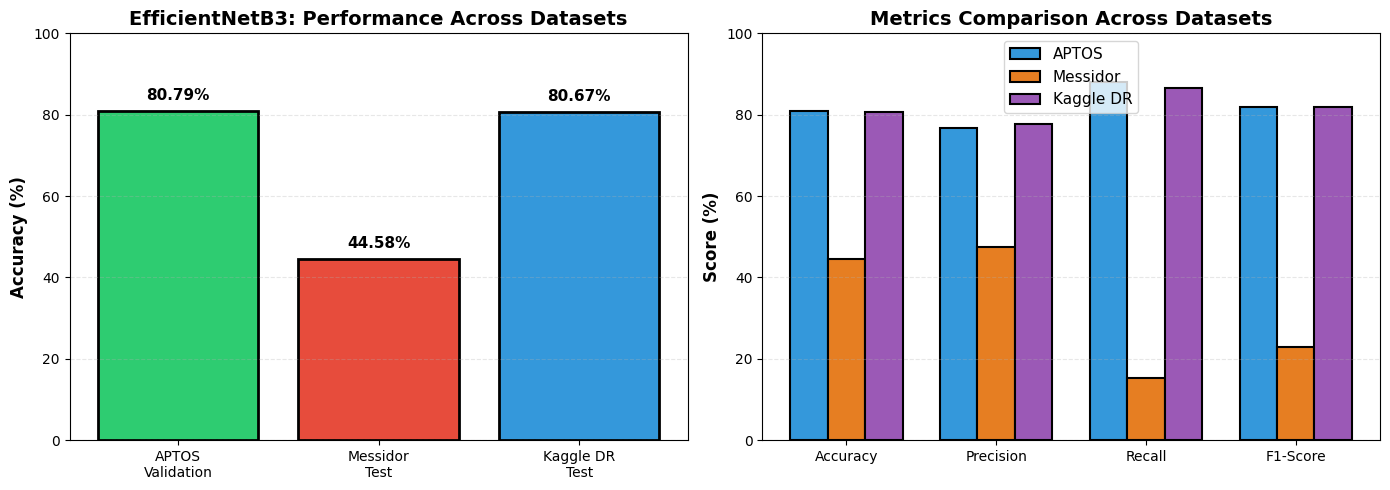

Saved: efficientnetb3_summary_table.png


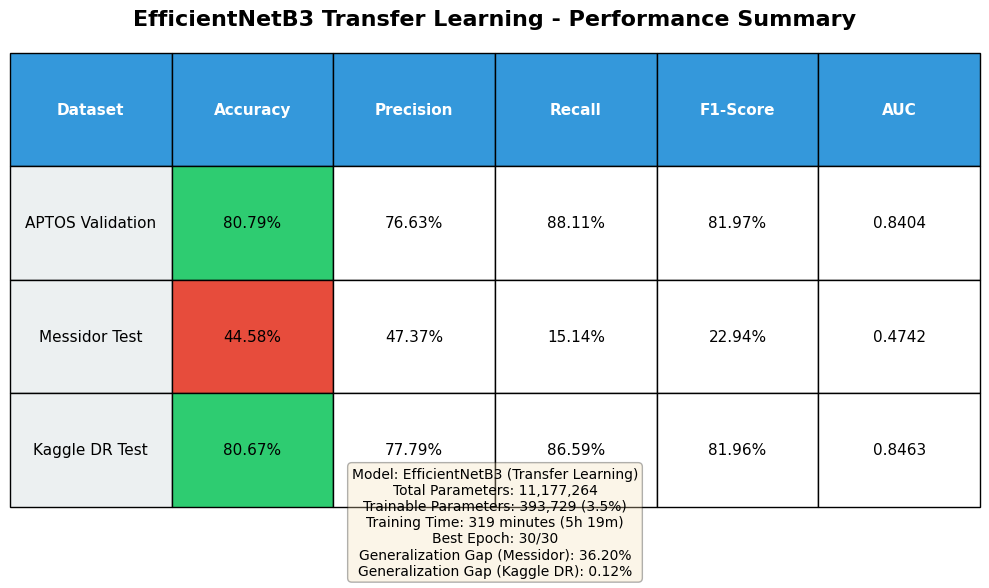

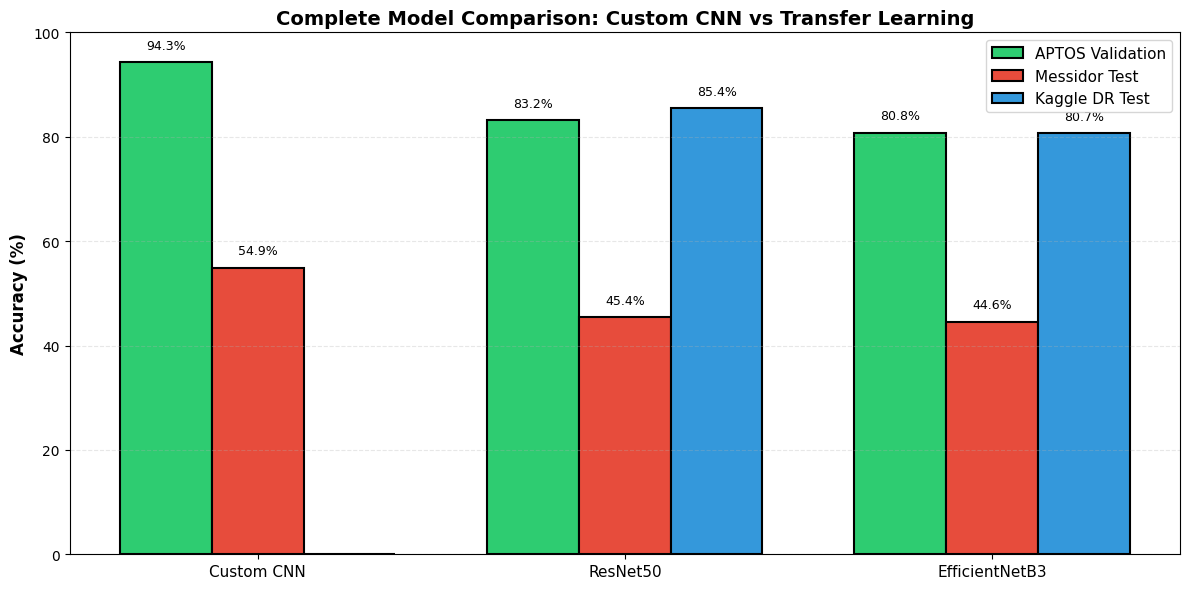

In [11]:
import matplotlib.pyplot as plt
import numpy as np

print("Creating EfficientNetB3 Visualizations...")

aptos_metrics = [80.79, 76.63, 88.11, 81.97]
messidor_metrics = [44.58, 47.37, 15.14, 22.94]
kaggle_metrics = [80.67, 77.79, 86.59, 81.96]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = ['APTOS\nValidation', 'Messidor\nTest', 'Kaggle DR\nTest']
accuracies = [80.79, 44.58, 80.67]
colors = ['#2ecc71', '#e74c3c', '#3498db']

bars = axes[0].bar(datasets, accuracies, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylim([0, 100])
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('EfficientNetB3: Performance Across Datasets', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.2f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

bars1 = axes[1].bar(x - width, aptos_metrics, width, label='APTOS',
                   color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = axes[1].bar(x, messidor_metrics, width, label='Messidor',
                   color='#e67e22', edgecolor='black', linewidth=1.5)
bars3 = axes[1].bar(x + width, kaggle_metrics, width, label='Kaggle DR',
                   color='#9b59b6', edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Metrics Comparison Across Datasets', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=10)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'efficientnetb3_performance_comparison.png'), dpi=300, bbox_inches='tight')
print("Saved: efficientnetb3_performance_comparison.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

summary_data = [
    ['APTOS Validation', '80.79%', '76.63%', '88.11%', '81.97%', '0.8404'],
    ['Messidor Test', '44.58%', '47.37%', '15.14%', '22.94%', '0.4742'],
    ['Kaggle DR Test', '80.67%', '77.79%', '86.59%', '81.96%', '0.8463']
]

table = ax.table(cellText=summary_data,
                colLabels=['Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(6):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

table[(1, 0)].set_facecolor('#ecf0f1')
table[(2, 0)].set_facecolor('#ecf0f1')
table[(3, 0)].set_facecolor('#ecf0f1')

table[(1, 1)].set_facecolor('#2ecc71')
table[(2, 1)].set_facecolor('#e74c3c')
table[(3, 1)].set_facecolor('#2ecc71')

ax.axis('off')
ax.set_title('EfficientNetB3 Transfer Learning - Performance Summary', fontsize=16, fontweight='bold', pad=20)

info_text = 'Model: EfficientNetB3 (Transfer Learning)\n'
info_text += 'Total Parameters: 11,177,264\n'
info_text += 'Trainable Parameters: 393,729 (3.5%)\n'
info_text += 'Training Time: 319 minutes (5h 19m)\n'
info_text += 'Best Epoch: 30/30\n'
info_text += 'Generalization Gap (Messidor): 36.20%\n'
info_text += 'Generalization Gap (Kaggle DR): 0.12%'

ax.text(0.5, -0.15, info_text, transform=ax.transAxes,
        fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'efficientnetb3_summary_table.png'), dpi=300, bbox_inches='tight')
print("Saved: efficientnetb3_summary_table.png")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))

models_list = ['Custom CNN', 'ResNet50', 'EfficientNetB3']
aptos_scores = [94.32, 83.19, 80.79]
messidor_scores = [54.92, 45.42, 44.58]
kaggle_scores = [0, 85.42, 80.67]

x = np.arange(len(models_list))
width = 0.25

bars1 = ax.bar(x - width, aptos_scores, width, label='APTOS Validation',
               color='#2ecc71', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, messidor_scores, width, label='Messidor Test',
               color='#e74c3c', edgecolor='black', linewidth=1.5)
bars3 = ax.bar(x + width, kaggle_scores, width, label='Kaggle DR Test',
               color='#3498db', edgecolor='black', linewidth=1.5)

ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Complete Model Comparison: Custom CNN vs Transfer Learning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'all_models_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
